In [1]:
import numpy as np
import pandas as pd
import time
import joblib
import os

# Create the models directory if it doesn't exist
os.makedirs('../models', exist_ok=True)

# 1. Load Original Data (75-patient test set)
print("Loading Original Dataset...")
X_train_orig = pd.read_csv('../dataset/processed/X_train.csv').values
y_train_orig = pd.read_csv('../dataset/processed/Y_train.csv').values.ravel()
X_test_orig = pd.read_csv('../dataset/processed/X_test.csv').values
y_test_orig = pd.read_csv('../dataset/processed/Y_test.csv').values.ravel()

# 2. Load New Merged Data (Generalized dataset)
print("Loading Generalized Merged Dataset...")
X_train_merged = pd.read_csv('../dataset/processed_merged/X_train.csv').values
y_train_merged = pd.read_csv('../dataset/processed_merged/Y_train.csv').values.ravel()
X_test_merged = pd.read_csv('../dataset/processed_merged/X_test.csv').values
y_test_merged = pd.read_csv('../dataset/processed_merged/Y_test.csv').values.ravel()

print(f"Original Training Size: {X_train_orig.shape[0]} patients")
print(f"Merged Training Size: {X_train_merged.shape[0]} patients")

Loading Original Dataset...
Loading Generalized Merged Dataset...
Original Training Size: 304 patients
Merged Training Size: 460 patients


In [2]:
import numpy as np
import pandas as pd

class SVM_From_Scratch:
    def __init__(self, learning_rate=0.001, lambda_param=0.01, n_iters=1000):
        # learning_rate: How big of a step the model takes when adjusting the line
        # lambda_param: The regularization penalty (controls the width of the margin)
        # n_iters: How many times we loop over the data to learn
        self.lr = learning_rate
        self.lambda_param = lambda_param
        self.n_iters = n_iters
        self.w = None # Weights (coefficients for features like eTIV, nWBV)
        self.b = None # Bias (the intercept)

    def fit(self, X, y):
        # CRITICAL MATH STEP: SVM math strictly requires labels to be -1 and 1.
        # Our current data has 0 (Healthy) and 1 (Demented). We must temporarily map 0 to -1.
        y_ = np.where(y <= 0, -1, 1)
        
        n_samples, n_features = X.shape
        
        # Initialize weights and bias to zeros
        self.w = np.zeros(n_features)
        self.b = 0

        # Gradient Descent: The learning loop
        for _ in range(self.n_iters):
            for idx, x_i in enumerate(X):
                # The Margin Equation: y_i * (w.x - b) >= 1
                condition = y_[idx] * (np.dot(x_i, self.w) - self.b) >= 1
                
                if condition:
                    # Point is correctly classified and safely outside the margin.
                    # We only apply a small regularization penalty to keep weights small.
                    self.w -= self.lr * (2 * self.lambda_param * self.w)
                else:
                    # Point is inside the margin or completely misclassified! (Hinge Loss)
                    # We heavily adjust the weights and the bias to fix this mistake.
                    self.w -= self.lr * (2 * self.lambda_param * self.w - np.dot(x_i, y_[idx]))
                    self.b -= self.lr * y_[idx]

    def predict(self, X):
        # Calculate the linear equation: w.x - b
        approx = np.dot(X, self.w) - self.b
        
        # np.sign returns 1 if positive, -1 if negative
        predictions = np.sign(approx)
        
        # Map the predictions back to 0 and 1 so they match our project requirements
        return np.where(predictions == -1, 0, 1)

# --- Quick Sanity Check ---
# Let's test it with dummy data to prove it learns
X_dummy = np.array([[1, 2], [1.5, 1.8], [8, 8], [9, 9.5]]) # Features
y_dummy = np.array([0, 0, 1, 1])                           # Labels

test_svm = SVM_From_Scratch(n_iters=1000)
test_svm.fit(X_dummy, y_dummy)
print("Dummy Predictions:", test_svm.predict(X_dummy))
print("Final Weights:", test_svm.w)

Dummy Predictions: [0 0 1 1]
Final Weights: [ 0.58960809 -0.29040453]


In [3]:
def calculate_accuracy(y_true, y_pred):
    return np.sum(y_true == y_pred) / len(y_true)

def calculate_recall(y_true, y_pred):
    true_positives = np.sum((y_true == 1) & (y_pred == 1))
    false_negatives = np.sum((y_true == 1) & (y_pred == 0))
    if (true_positives + false_negatives) == 0: return 0
    return true_positives / (true_positives + false_negatives)

def calculate_f1(y_true, y_pred):
    true_positives = np.sum((y_true == 1) & (y_pred == 1))
    false_positives = np.sum((y_true == 0) & (y_pred == 1))
    precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
    recall = calculate_recall(y_true, y_pred)
    if (precision + recall) == 0: return 0
    return 2 * (precision * recall) / (precision + recall)

In [4]:
# --- EXPERIMENT A: ORIGINAL DATA ---
print("--- MODEL A: ORIGINAL DATASET (LINEAR SVM) ---")
start_time = time.time()
svm_original = SVM_From_Scratch(learning_rate=0.001, lambda_param=0.01, n_iters=2000)
svm_original.fit(X_train_orig, y_train_orig)
print(f"Training Time: {time.time() - start_time:.2f} seconds")

preds_orig = svm_original.predict(X_test_orig)
print(f"Accuracy: {calculate_accuracy(y_test_orig, preds_orig):.4f}")
print(f"Recall:   {calculate_recall(y_test_orig, preds_orig):.4f}")
print(f"F1-Score: {calculate_f1(y_test_orig, preds_orig):.4f}")

# Save the original model
joblib.dump(svm_original, '../models/svm_original.joblib')


# --- EXPERIMENT B: MERGED DATA ---
print("\n--- MODEL B: GENERALIZED MERGED DATASET (LINEAR SVM) ---")
start_time = time.time()
svm_merged = SVM_From_Scratch(learning_rate=0.001, lambda_param=0.01, n_iters=2000)
svm_merged.fit(X_train_merged, y_train_merged)
print(f"Training Time: {time.time() - start_time:.2f} seconds")

preds_merged = svm_merged.predict(X_test_merged)
print(f"Accuracy: {calculate_accuracy(y_test_merged, preds_merged):.4f}")
print(f"Recall:   {calculate_recall(y_test_merged, preds_merged):.4f}")
print(f"F1-Score: {calculate_f1(y_test_merged, preds_merged):.4f}")

# Save the generalized model
joblib.dump(svm_merged, '../models/svm_merged.joblib')

print("\nModels successfully saved to the '../models/' directory.")

--- MODEL A: ORIGINAL DATASET (LINEAR SVM) ---
Training Time: 18.14 seconds
Accuracy: 0.7467
Recall:   0.6757
F1-Score: 0.7246

--- MODEL B: GENERALIZED MERGED DATASET (LINEAR SVM) ---
Training Time: 15.92 seconds
Accuracy: 0.7826
Recall:   0.7018
F1-Score: 0.7619

Models successfully saved to the '../models/' directory.


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.decomposition import PCA
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

# The exact feature order from your preprocessed data
feature_names = ['M/F', 'Age', 'EDUC', 'SES', 'MMSE', 'eTIV', 'nWBV', 'ASF']

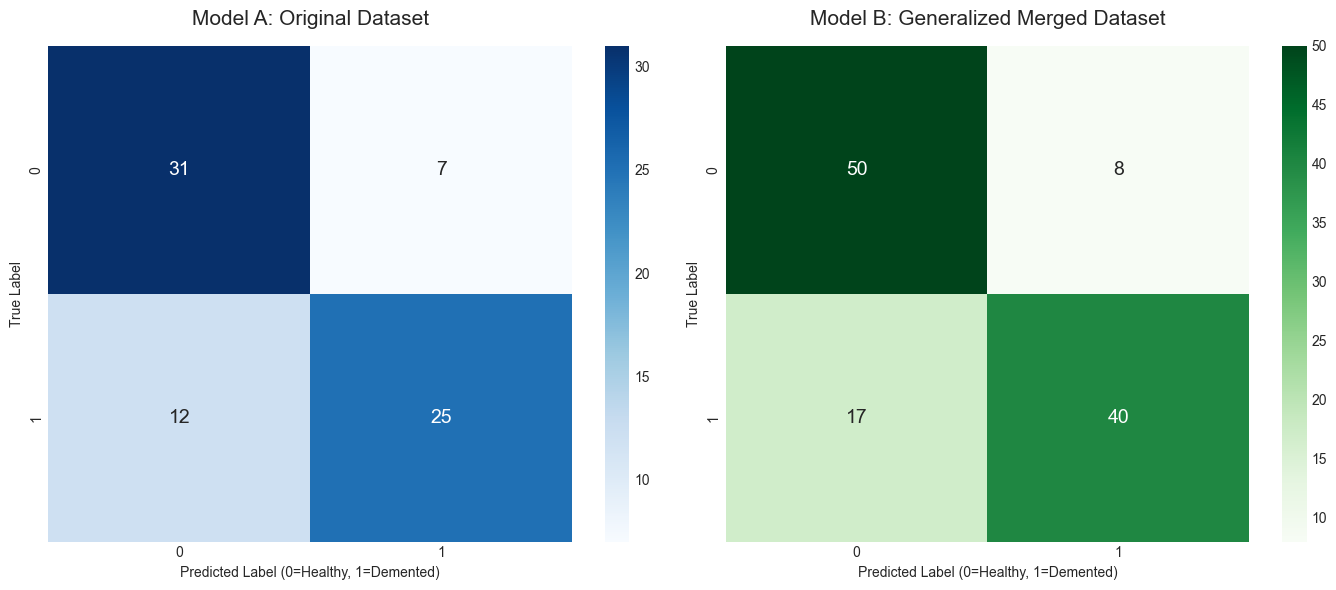

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Original Dataset Confusion Matrix
cm_orig = confusion_matrix(y_test_orig, preds_orig)
sns.heatmap(cm_orig, annot=True, fmt='d', cmap='Blues', ax=axes[0], annot_kws={"size": 14})
axes[0].set_title('Model A: Original Dataset', fontsize=15, pad=15)
axes[0].set_xlabel('Predicted Label (0=Healthy, 1=Demented)')
axes[0].set_ylabel('True Label')

# 2. Merged Dataset Confusion Matrix
cm_merged = confusion_matrix(y_test_merged, preds_merged)
sns.heatmap(cm_merged, annot=True, fmt='d', cmap='Greens', ax=axes[1], annot_kws={"size": 14})
axes[1].set_title('Model B: Generalized Merged Dataset', fontsize=15, pad=15)
axes[1].set_xlabel('Predicted Label (0=Healthy, 1=Demented)')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.savefig('../figures/svm_confusion_matrices.png', dpi=300)
plt.show()

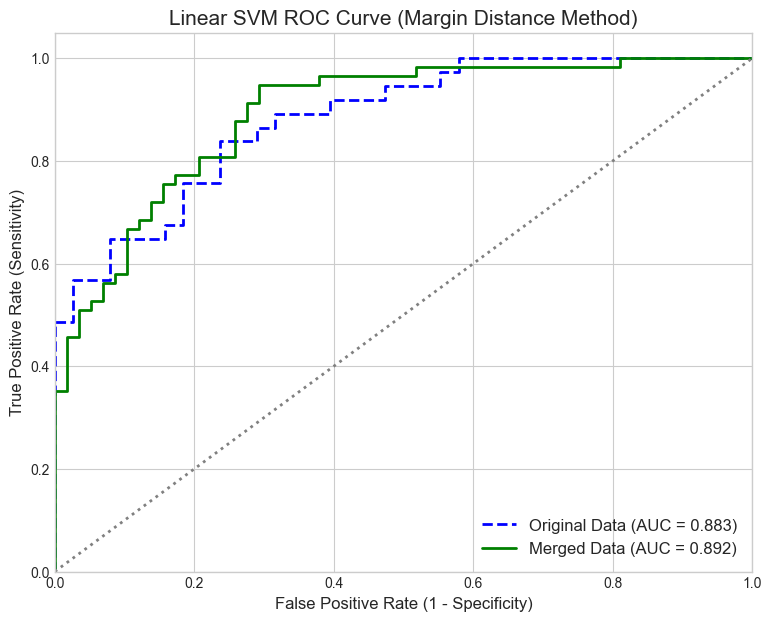

In [10]:
# Calculate distance to the decision boundary (w*x - b) for confidence scores
scores_orig = np.dot(X_test_orig, svm_original.w) - svm_original.b
scores_merged = np.dot(X_test_merged, svm_merged.w) - svm_merged.b

# Calculate ROC metrics
fpr_orig, tpr_orig, _ = roc_curve(y_test_orig, scores_orig)
auc_orig = auc(fpr_orig, tpr_orig)

fpr_merged, tpr_merged, _ = roc_curve(y_test_merged, scores_merged)
auc_merged = auc(fpr_merged, tpr_merged)

# Plot
plt.figure(figsize=(9, 7))
plt.plot(fpr_orig, tpr_orig, color='blue', lw=2, linestyle='--', label=f'Original Data (AUC = {auc_orig:.3f})')
plt.plot(fpr_merged, tpr_merged, color='green', lw=2, label=f'Merged Data (AUC = {auc_merged:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle=':')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title('Linear SVM ROC Curve (Margin Distance Method)', fontsize=15)
plt.legend(loc="lower right", fontsize=12)

plt.savefig('../figures/svm_roc_curve.png', dpi=300)
plt.show()

Extracting learned Support Vector coefficients (weights)...


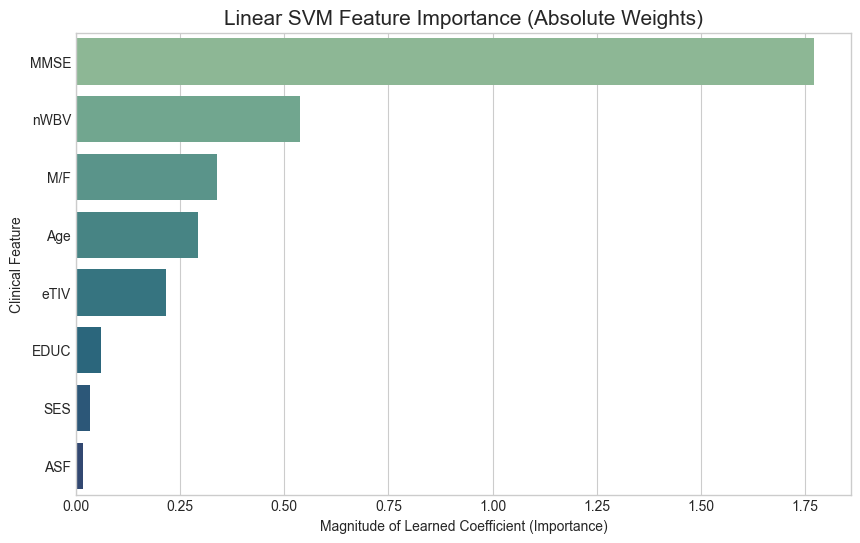

In [11]:
print("Extracting learned Support Vector coefficients (weights)...")

# Get absolute values of the learned weights from the generalized SVM model
svm_importance_weights = np.abs(svm_merged.w)

# Create a DataFrame for sorting and plotting
importance_df = pd.DataFrame({
    'Feature': feature_names, 
    'Weight Magnitude': svm_importance_weights
})
# Sort by highest weight
importance_df = importance_df.sort_values(by='Weight Magnitude', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Weight Magnitude', y='Feature', data=importance_df, palette='crest')
plt.title('Linear SVM Feature Importance (Absolute Weights)', fontsize=15)
plt.xlabel('Magnitude of Learned Coefficient (Importance)')
plt.ylabel('Clinical Feature')

plt.savefig('../figures/svm_feature_importance.png', dpi=300)
plt.show()

Training 2D Linear SVM for Visualization...


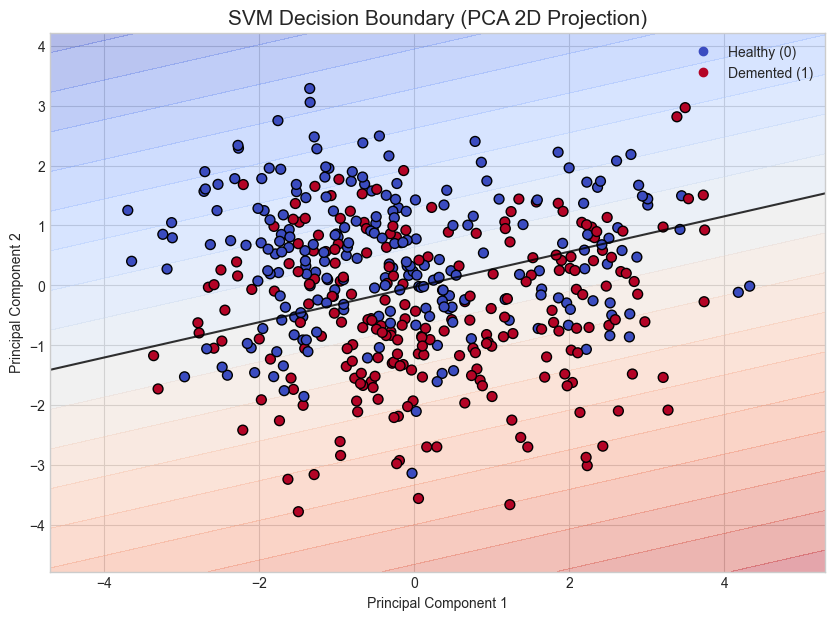

In [12]:
# 1. Compress features to 2D using PCA
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_merged)
y_train_pca = y_train_merged

# 2. Train a 2D Presentation SVM Model
print("Training 2D Linear SVM for Visualization...")
svm_2d = SVM_From_Scratch(learning_rate=0.001, lambda_param=0.01, n_iters=1000)
svm_2d.fit(X_train_pca, y_train_pca)

# 3. Create the mesh grid (background pixels)
x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))

# 4. Predict distance to the margin across the grid
grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = np.dot(grid_points, svm_2d.w) - svm_2d.b
Z = Z.reshape(xx.shape)

# 5. Plot
plt.figure(figsize=(10, 7))
# Heatmap background showing distance to margin
plt.contourf(xx, yy, Z, alpha=0.4, cmap='coolwarm', levels=20)
# Draw the stark black line where the actual decision boundary lies (Z = 0)
plt.contour(xx, yy, Z, colors='k', levels=[0], alpha=0.8, linestyles=['-']) 

scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train_pca, cmap='coolwarm', edgecolor='k', s=50)

plt.title('SVM Decision Boundary (PCA 2D Projection)', fontsize=15)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(handles=scatter.legend_elements()[0], labels=['Healthy (0)', 'Demented (1)'], loc="upper right")

plt.savefig('../figures/svm_decision_boundary.png', dpi=300)
plt.show()